### Práctica de transformer

  1. Entrenar un transformer con la función seno y predecir 50 valores subsiguientes.
  2. Entrenar un transformer con el precio diario de Apple (AAPL) y predecir 50 valores subsiguientes.


##### Crea los datos de la función seno

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# 1. Crear la onda seno
t = np.linspace(0, 100, 1000) # 1000 puntos de 0 a 100
data = np.sin(t).reshape(-1, 1)

# 2. Función para crear ventanas (Secuencias)
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 50 
X, y = create_sequences(data, seq_length)

# Convertir a Tensores
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # para nvidia
print(device)
X = torch.from_numpy(X).float().to(device)
y = torch.from_numpy(y).float().to(device)

cpu


##### grafica de la onda seno

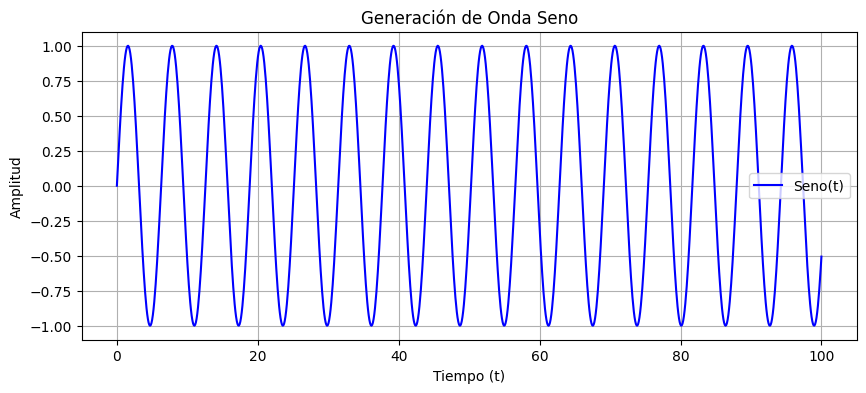

In [14]:
plt.figure(figsize=(10, 4))             
plt.plot(t, data, color='b', label='Seno(t)') 
plt.title('Generación de Onda Seno')   
plt.xlabel('Tiempo (t)')                
plt.ylabel('Amplitud')                 
plt.grid(True)                         
plt.legend()                            
plt.show()                            

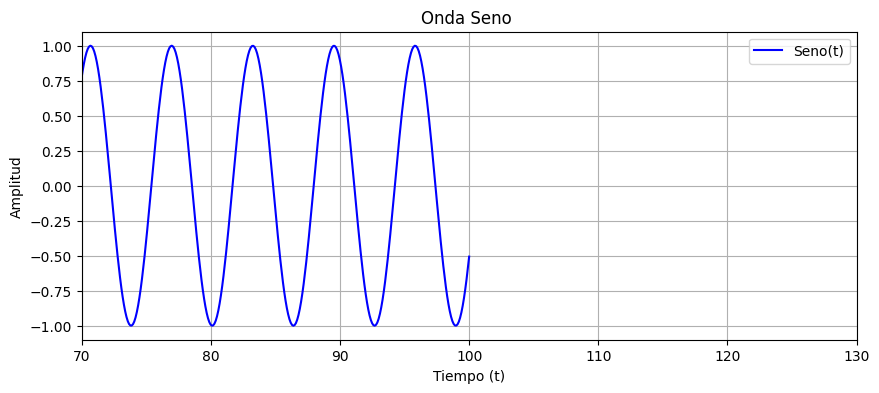

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(t, data, color='b', label='Seno(t)') 
plt.title('Onda Seno ')
plt.xlabel('Tiempo (t)')
plt.ylabel('Amplitud')
plt.xlim(70, 130) 
plt.grid(True)
plt.legend()
plt.show()

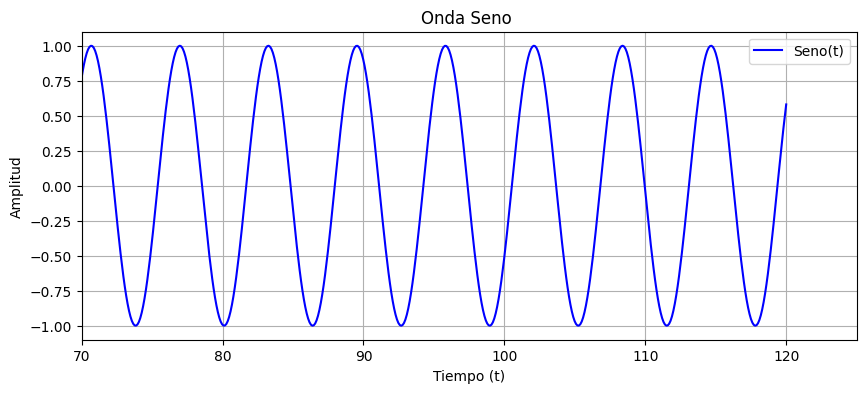

In [22]:
t_real = np.linspace(0, 120, 1200) 
data_real = np.sin(t_real).reshape(-1, 1)

plt.figure(figsize=(10, 4))
plt.plot(t_real, data_real, color='b', label='Seno(t)') 
plt.title('Onda Seno ')
plt.xlabel('Tiempo (t)')
plt.ylabel('Amplitud')
plt.xlim(70, 125) 
plt.grid(True)
plt.legend()
plt.show()


##### Define la red completa

In [4]:
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        seq_len = x.size(1)
        x = x + self.pe[:, :seq_len, :]
        return x


class SequenceTransformer(nn.Module):
    def __init__(self, input_dim=1, d_model=32, nhead=4, num_layers=2, dim_feedforward=64, dropout=0.1):
        super().__init__()
        
        self.input_projection = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )
        
        self.fc_out = nn.Linear(d_model, 1)

    def forward(self, x):
        # x shape: (batch_size, seq_len, 1)
        x = self.input_projection(x)         # (batch_size, seq_len, d_model)
        x = self.pos_encoder(x)              # agrega información de posición
        x = self.transformer_encoder(x)      # (batch_size, seq_len, d_model)
        
        x = x[:, -1, :]                      # usamos la última posición
        out = self.fc_out(x)                 # (batch_size, 1)
        
        return out
    
model = SequenceTransformer().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

model

SequenceTransformer(
  (input_projection): Linear(in_features=1, out_features=32, bias=True)
  (pos_encoder): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=64, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc_out): Linear(in_features=32, out_features=1, bias=True)
)

##### Entrena

C:\Users\emlom\AppData\Local\Temp\ipykernel_13472\2029460374.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_batch = torch.tensor(X, dtype=torch.float32).to(device)
C:\Users\emlom\AppData\Local\Temp\ipykernel_13472\2029460374.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_batch = torch.tensor(y, dtype=torch.float32).to(device)


Epoch [10/100], Loss: 0.101781
Epoch [20/100], Loss: 0.051552
Epoch [30/100], Loss: 0.014821
Epoch [40/100], Loss: 0.012548
Epoch [50/100], Loss: 0.010663
Epoch [60/100], Loss: 0.009042
Epoch [70/100], Loss: 0.007636
Epoch [80/100], Loss: 0.007894
Epoch [90/100], Loss: 0.006981
Epoch [100/100], Loss: 0.006433


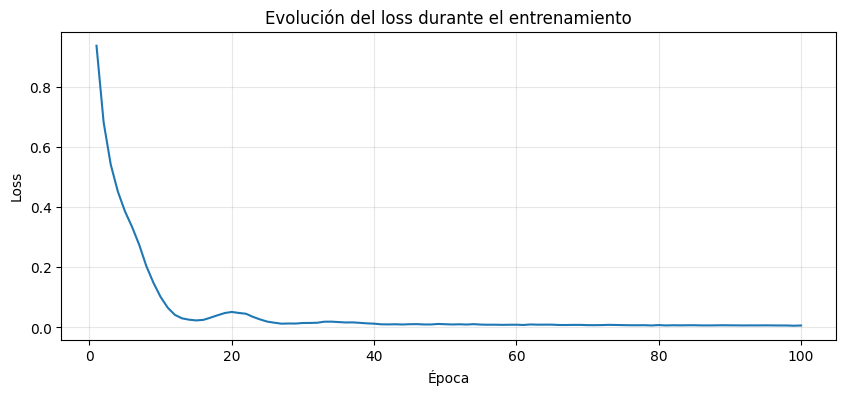

In [5]:
# TO-DO
losses = []
epochs = 100

for epoch in range(epochs):
    model.train()

    X_batch = torch.tensor(X, dtype=torch.float32).to(device)
    y_batch = torch.tensor(y, dtype=torch.float32).to(device)

    optimizer.zero_grad()
    output = model(X_batch)
    loss = criterion(output, y_batch)
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")
        
plt.figure(figsize=(10,4))
plt.plot(range(1, epochs + 1), losses)
plt.title("Evolución del loss durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.show()

##### Calcula los puntos siguientes

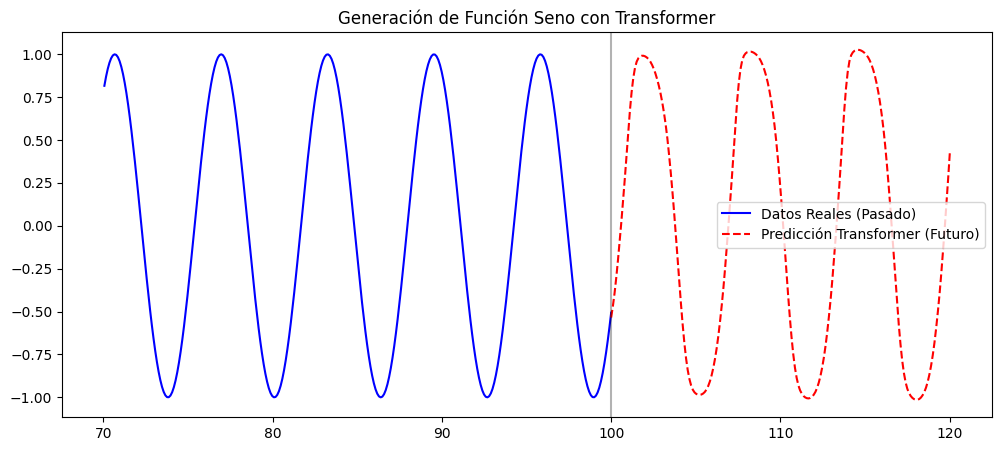

In [6]:
model.eval()
future_points = 200
predictions = []

# Tomamos la última ventana de los datos reales para empezar
last_sequence = X[-1].unsqueeze(0) 

for _ in range(future_points):
    with torch.no_grad():
        pred = model(last_sequence) # Predice el siguiente punto
        predictions.append(pred.item())
        
        # Actualizamos la ventana: desplazamos y añadimos la predicción
        new_row = pred.unsqueeze(1) 
        last_sequence = torch.cat((last_sequence[:, 1:, :], new_row), dim=1)

# Pintar resultados
plt.figure(figsize=(12,5))
plt.plot(t[-300:], data[-300:], label="Datos Reales (Pasado)", color="blue")
plt.plot(np.linspace(t[-1], t[-1]+20, future_points), predictions, label="Predicción Transformer (Futuro)", linestyle="--", color="red")
plt.axvline(x=t[-1], color='black', alpha=0.3)
plt.legend()
plt.title("Generación de Función Seno con Transformer")
plt.show()

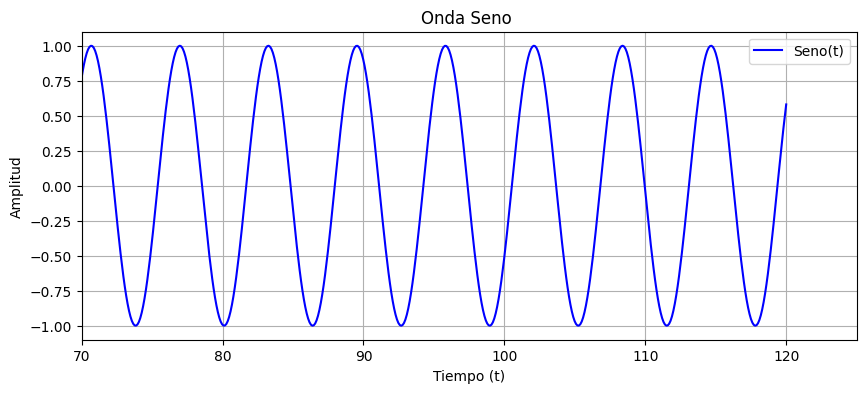

In [23]:
plt.figure(figsize=(10, 4))
plt.plot(t_real, data_real, color='b', label='Seno(t)') 
plt.title('Onda Seno ')
plt.xlabel('Tiempo (t)')
plt.ylabel('Amplitud')
plt.xlim(70, 125) 
plt.grid(True)
plt.legend()
plt.show()


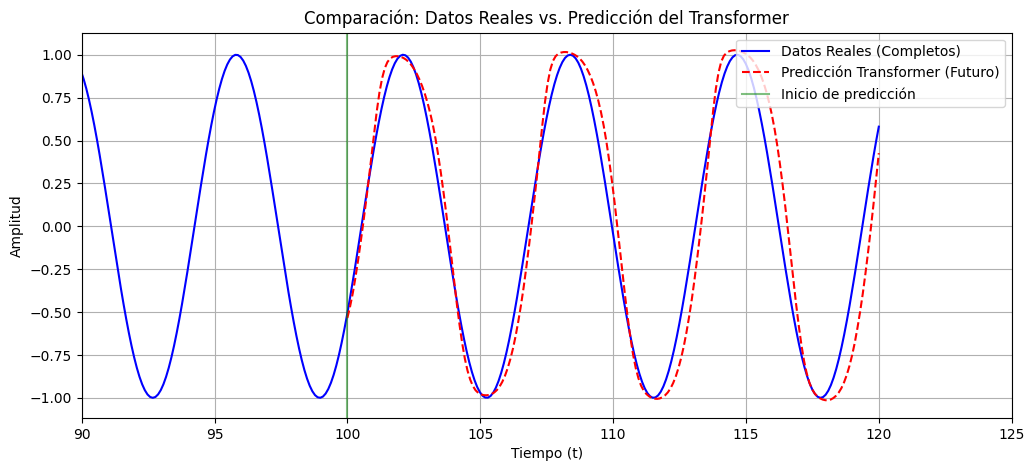

In [29]:
# Crear la figura con un buen tamaño
plt.figure(figsize=(12, 5))

# 1. Graficar TODOS los datos reales (pasado y futuro real)
plt.plot(t_real, data_real, color='blue', label='Datos Reales (Completos)')

# 2. Recrear el eje X para las predicciones (basado en tu código del Transformer)
t_preds = np.linspace(t[-1], t[-1] + 20, future_points)

# 3. Graficar las predicciones del Transformer superpuestas
plt.plot(t_preds, predictions, color='red', linestyle='--', label='Predicción Transformer (Futuro)')

# 4. Añadir una línea vertical para marcar dónde empieza el futuro
plt.axvline(x=t[-1], color='green', alpha=0.5, label='Inicio de predicción')

# 5. Aplicar el zoom para enfocarnos en la zona interesante (por ejemplo, de 90 a 125)
plt.xlim(90, 125) 

# Configuraciones finales
plt.title('Comparación: Datos Reales vs. Predicción del Transformer')
plt.xlabel('Tiempo (t)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.legend(loc='upper right') # Coloca la leyenda arriba a la derecha para no tapar la onda
plt.show()

#### Acciones de Apple

In [25]:
%pip install --upgrade yfinance

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Configuración de dispositivo (GPU si está disponible)
device = torch.device('mps' if torch.mps.is_available() else 'cpu')

Defaulting to user installation because normal site-packages is not writeable
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 9.6 MB/s eta 0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15703 sha256=721e0b8ec4dba6aefa5e5cb4fd307a76c78f84e1815b42ed4229a7bc87e89931
  Stored in directory: c:\users\emlom\appdata\local\pip\cache\wheels\cc\bd\6f\664d62c99327abeef7d86489e6631cbf45b56fbf7ef1d6ef00
Successfully built multitasking
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\emlom\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
# Descargar datos
df = yf.download('AAPL', start='2020-01-01', end='2026-01-01')
data = df['Close'].values.reshape(-1, 1)

# Normalización (Importante para Transformers)
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

# Función para crear secuencias
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 60 # Usamos 60 días previos para predecir el siguiente
X, y = create_sequences(data_scaled, seq_length)

# Convertir a Tensores de PyTorch
X = torch.from_numpy(X).float().to(device)
y = torch.from_numpy(y).float().to(device)

print(f"Forma de X: {X.shape}") # [muestras, seq_length, 1]

[*********************100%***********************]  1 of 1 completed

Forma de X: torch.Size([1448, 60, 1])


Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.400528  72.460791  71.156689  71.409793  135480400
2020-01-03  71.696632  72.455950  71.472454  71.629138  146322800
2020-01-06  72.267929  72.306499  70.568503  70.819201  118387200
2020-01-07  71.928055  72.533095  71.708695  72.277578  108872000
2020-01-08  73.085129  73.386446  71.631574  71.631574  132079200


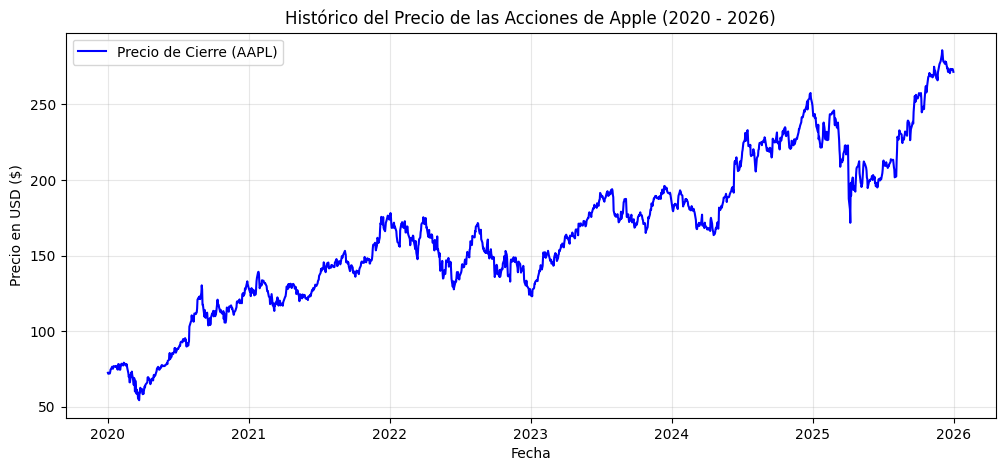

In [32]:
# Ver primeras filas
print(df.head())

plt.figure(figsize=(12, 5))

# Graficar los datos usando el índice (fechas) y la columna 'Close'
plt.plot(df.index, df['Close'], color='blue', label='Precio de Cierre (AAPL)')

# Personalizar el gráfico
plt.title('Histórico del Precio de las Acciones de Apple (2020 - 2026)')
plt.xlabel('Fecha')
plt.ylabel('Precio en USD ($)')
plt.grid(True, alpha=0.3)  # alpha hace que la cuadrícula sea más suave
plt.legend()

# Mostrar la gráfica
plt.show()

In [ ]:
class PositionalEncodingApple(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncodingApple, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # shape: (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_size=1, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super(TimeSeriesTransformer, self).__init__()

        # Proyección de la entrada de 1 dimensión a d_model
        self.input_projection = nn.Linear(input_size, d_model)

        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model, dropout)

        # Capa encoder del Transformer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=128,
            dropout=dropout,
            batch_first=True
        )

        # Encoder completo
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # Capa final para predecir un valor
        self.fc_out = nn.Linear(d_model, 1)

    def forward(self, x):
        # Si entra como (batch, seq_len), lo convertimos a (batch, seq_len, 1)
        if x.dim() == 2:
            x = x.unsqueeze(-1)

        # Proyección inicial
        x = self.input_projection(x)   # (batch, seq_len, d_model)

        # Agregar información posicional
        x = self.pos_encoder(x)

        # Pasar por el encoder
        x = self.transformer_encoder(x)  # (batch, seq_len, d_model)

        # Tomamos la última posición temporal
        x = x[:, -1, :]  # (batch, d_model)

        # Predicción final
        out = self.fc_out(x)  # (batch, 1)
        return out

model_apple = TimeSeriesTransformer().to(device)
criterion_apple = nn.MSELoss()
optimizer_apple = torch.optim.Adam(model_apple.parameters(), lr=0.001)

model_apple

TimeSeriesTransformer(
  (input_projection): Linear(in_features=1, out_features=64, bias=True)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc_out): Linear(in_features=64, out_features=1, bias=True)
)

In [ ]:
# entrena
# TO-DO

In [ ]:
model.eval()
future_predictions = []
current_batch = X[-1].unsqueeze(0) # Tomamos la última secuencia conocida

for _ in range(50):
    with torch.no_grad():
        pred = model(current_batch)
        future_predictions.append(pred.item())
        
        # Actualizar la ventana: quitar el primero, añadir la predicción al final
        new_pred = pred.unsqueeze(1) # [1, 1, 1]
        current_batch = torch.cat((current_batch[:, 1:, :], new_pred), dim=1)

# Des-normalizar los resultados
future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(range(len(data)), scaler.inverse_transform(data_scaled), label='Histórico Real')
plt.plot(range(len(data), len(data) + 50), future_predictions, label='Predicción Futura (50 días)', color='red')
plt.title('Predicción AAPL con Transformer')
plt.legend()
plt.show()